In [19]:
import subprocess
subprocess.run(['pip', 'install', 'libpysal', 'esda'])

CompletedProcess(args=['pip', 'install', 'libpysal', 'esda'], returncode=0)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import xarray as xr
import rioxarray as rio
import geopandas as gpd

In [ ]:
# NO2 VCD GAPFILLED
# Path Data Time Series NO2 VCD
no2_vcd_path = r'D:\Kuliah UNDIP\Semester 7\TA\PENGOLAHAN\github\output\no2_gapfilled' 
no2_vcd_files = glob.glob(os.path.join(no2_vcd_path, 'no2gap_*.tif'))
no2_vcd_files.sort()


# Read All NO2 VCD
no2_vcd_dataset = []
for file in no2_vcd_files:
    data_no2_vcd = rio.open_rasterio(file)
    no2_vcd_dataset.append(data_no2_vcd)

# Extract Date
dates = [file.split('no2gap_')[-1].replace('.tif', '') for file in no2_vcd_files]
time_no2= pd.to_datetime(dates, format='%d_%m_%Y')

# Combined Dataset to Xarray
no2_vcd = xr.concat(no2_vcd_dataset, dim='time').squeeze('band')
no2_vcd['time'] = time_no2

# View generate metadata associated with the raster file
print("Bounding Box:", no2_vcd.rio.bounds())
print("The crs of your data is:", no2_vcd.rio.crs)
print("The nodatavalue of your data is:", no2_vcd.rio.nodata)
print("The shape of your data is:", no2_vcd.shape)
print("The spatial resolution for your data is:", no2_vcd.rio.resolution())
print("The metadata for your data is:", no2_vcd.attrs)


Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: None
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2000000000007, 1113.1999999999714)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': 'no2_vcd_filled'}


# **Hotspot Metode Top 20% Persentil - Monthly**

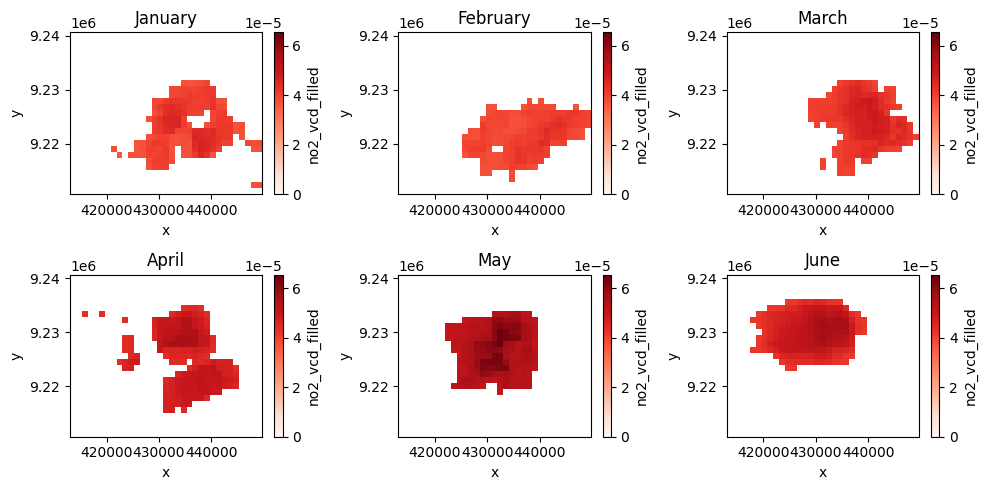

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

monthly_mean = no2_vcd.groupby('time.month').mean(dim='time')

fig, axes = plt.subplots(2, 3, figsize=(10, 5))

month_name = ['January', 'February', 'March', 'April', 'May', 'June']

for i, ax in enumerate(axes.flatten()):
    if i < len(month_name):
        month_i = monthly_mean.sel(month=i+1)

        # threshold P80
        data = month_i.values.flatten()
        data = data[~np.isnan(data)]
        p80 = np.percentile(data, 80)

        hotspot_i = month_i.where(month_i >= p80)

        hotspot_i.plot(
            ax=ax,
            fontsize=12,
            cmap='Reds',
            vmin=0,
            vmax=np.nanmax(monthly_mean.values)
        )

        ax.set_title(month_name[i])
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

Luasan akan konstan karena ini metode persentil. Metode ini berguna untuk analisis distribusi spasial dari NO2. Bisa masukan insight pengaruh-pengaruhnya seperti jalan.

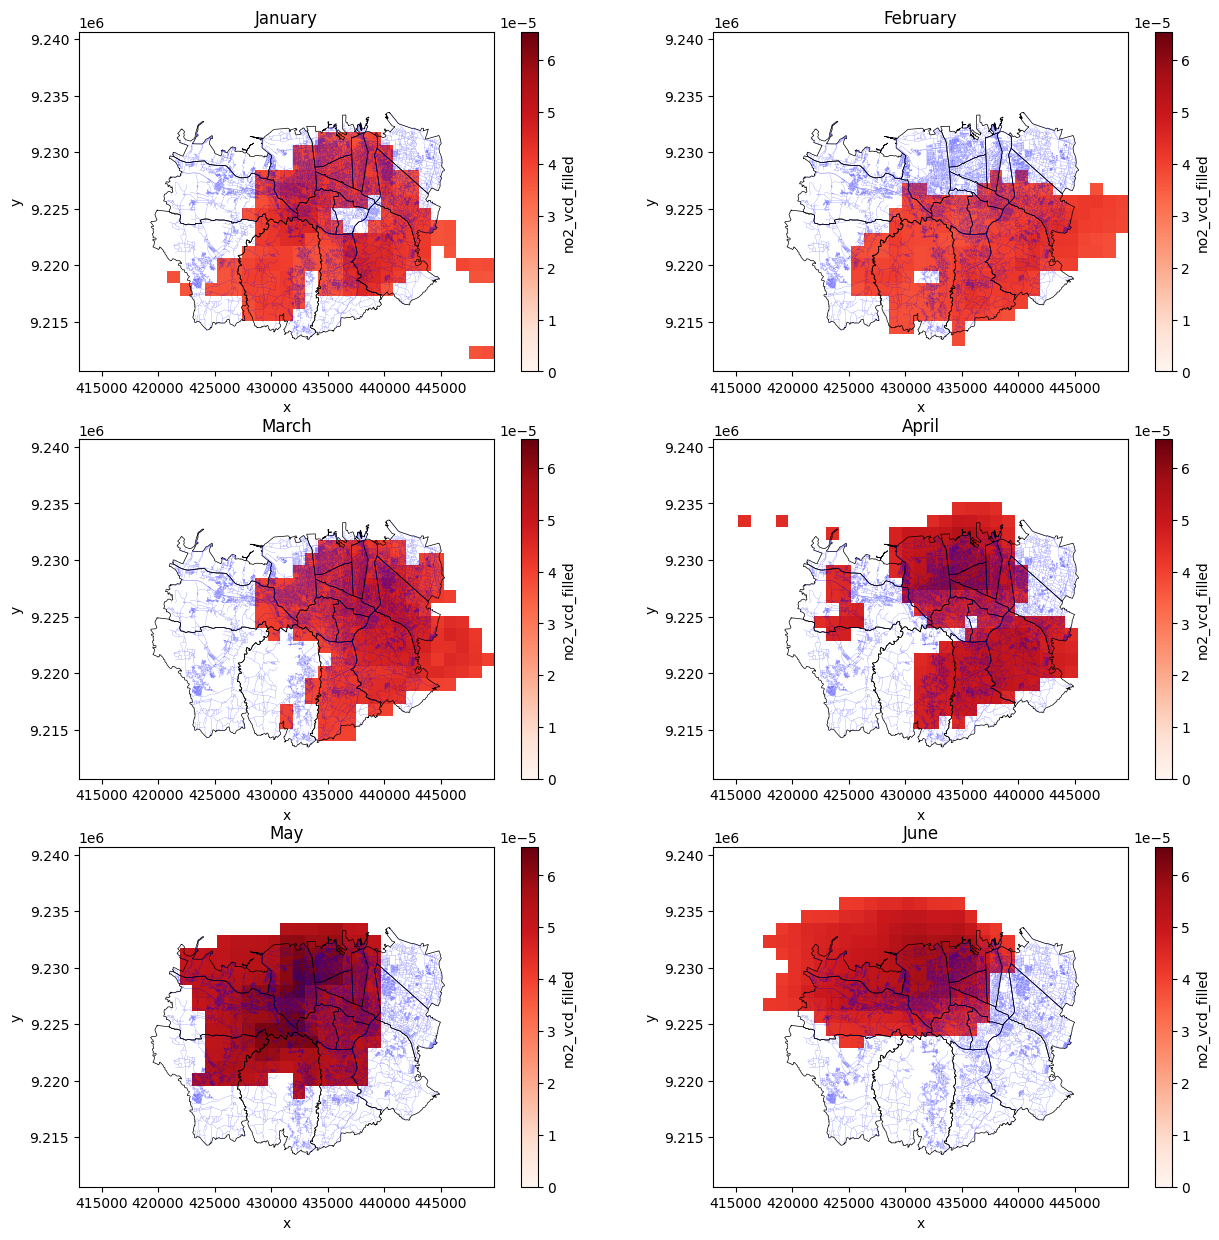

In [ ]:
# Import Shapefile Batas Administrasi Semarang
shapefile_batas = r'D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\SHP\BATAS ADMINISTRASI SEMARANG'
shapefile_kec = gpd.read_file(os.path.join(shapefile_batas, 'Kec_KotaSemarang.shp'))

# Import Shapefile Jalan Semarang
shapefile_jalan = r'D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\SHP\JALAN SEMARANG'
shapefile_jln= gpd.read_file(os.path.join(shapefile_jalan, 'JLN_KotaSemarang.shp'))

shapefile_kec = shapefile_kec.to_crs("EPSG:32749")
shapefile_jln = shapefile_jln.to_crs("EPSG:32749")

# Plotting
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
month_name = ['January', 'February', 'March', 'April', 'May', 'June']
for i, ax in enumerate(axes.flatten()):
    if i < len(month_name):
        month_i = monthly_mean.sel(month=i+1)

        # threshold P80
        data = month_i.values.flatten()
        data = data[~np.isnan(data)]
        p80 = np.percentile(data, 80)

        hotspot_i = month_i.where(month_i >= p80)

        hotspot_i.plot(
            ax=ax,
            cmap='Reds',
            vmin=0,
            vmax=np.nanmax(monthly_mean.values)
        )

        shapefile_kec.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)
        shapefile_jln.plot(ax=ax, color='blue', linewidth=0.1)

        ax.set_title(month_name[i])
    else:
        ax.axis('on')

In [ ]:
import pandas as pd
import numpy as np

month_name = ['January', 'February', 'March', 'April', 'May', 'June']

results = []

for i, m in enumerate(range(1, 7)):

    month_i = monthly_mean.sel(month=m)

    # flatten + remove NaN
    data = month_i.values.flatten()
    data = data[~np.isnan(data)]

    # P80
    p80 = np.percentile(data, 80)

    # top 20%
    hotspot_i = month_i.where(month_i >= p80)
    hotspot_vals = hotspot_i.values.flatten()
    hotspot_vals = hotspot_vals[~np.isnan(hotspot_vals)]

    # statistik
    min_hotspot = np.min(hotspot_vals)
    max_hotspot = np.max(hotspot_vals)
    mean_hotspot = np.mean(hotspot_vals)

    # simpan ke list
    results.append({
        'Bulan': month_name[i],
        'Threshold': p80,
        'Min Hotspot': min_hotspot,
        'Max Hotspot': max_hotspot,
        'Rata-Rata Hotspot': mean_hotspot,
    })

# convert ke dataframe
df_hotspot = pd.DataFrame(results)

print(df_hotspot)


      Bulan  Threshold  Min Hotspot  Max Hotspot  Rata-Rata Hotspot
0   January   0.000037     0.000037     0.000047           0.000041
1  February   0.000037     0.000037     0.000045           0.000040
2     March   0.000039     0.000039     0.000049           0.000043
3     April   0.000044     0.000044     0.000056           0.000049
4       May   0.000051     0.000051     0.000065           0.000056
5      June   0.000041     0.000041     0.000058           0.000048


In [ ]:
# export ke excel
output_path_hotspot = r'D:\Kuliah UNDIP\Semester 7\TA\PENGOLAHAN\github\output'
df_hotspot.to_excel(os.path.join(output_path_hotspot, 'hotspot_no2_vcd_summary.xlsx', index=False))

# **Hotspot Metode Top 20% Persentil - Weekly**

d:\Kuliah UNDIP\Semester 7\TA\PENGOLAHAN\github\venv\Lib\site-packages\xarray\core\dataset_utils.py:86: FutureWarning: dt.weekofyear and dt.week have been deprecated. Please use dt.isocalendar().week instead.
  data = getattr(ref_var.dt, var_name).data


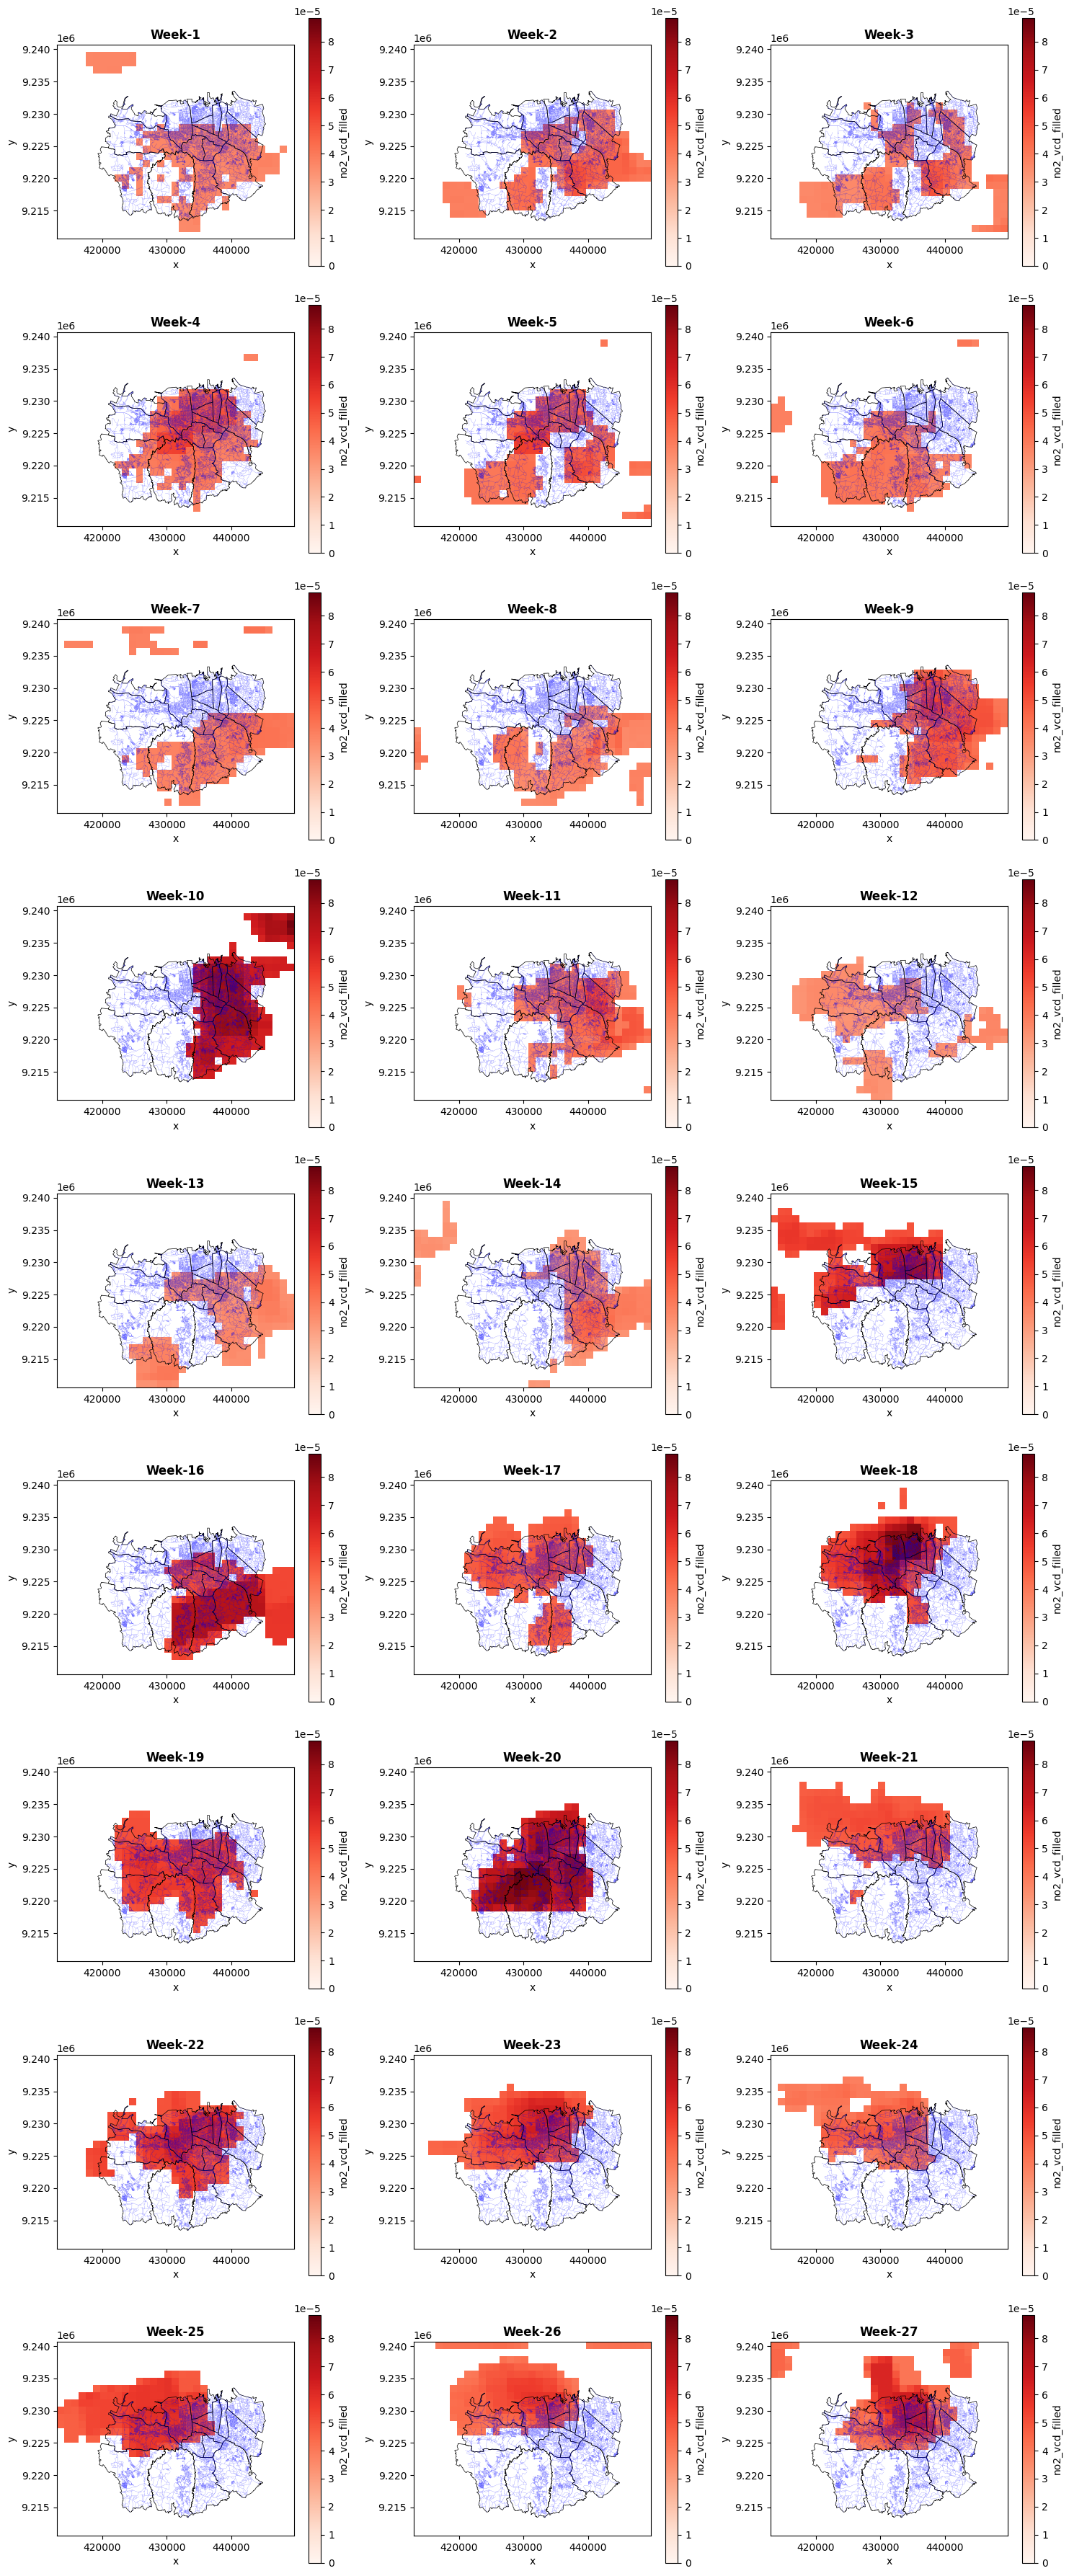

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Import Shapefile Batas Administrasi Semarang
shapefile_batas = r'D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\SHP\BATAS ADMINISTRASI SEMARANG'
shapefile_kec = gpd.read_file(os.path.join(shapefile_batas, 'Kec_KotaSemarang.shp'))

# Import Shapefile Jalan Semarang
shapefile_jalan = r'D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\SHP\JALAN SEMARANG'
shapefile_jln= gpd.read_file(os.path.join(shapefile_jalan, 'JLN_KotaSemarang.shp'))

shapefile_kec = shapefile_kec.to_crs("EPSG:32749")
shapefile_jln = shapefile_jln.to_crs("EPSG:32749")

weekly_mean = no2_vcd.groupby('time.week').mean(dim='time')

weeks = weekly_mean.week.values  # ambil semua nomor minggu
n_weeks = len(weeks)

# hitung jumlah baris yang dibutuhkan (3 kolom)
n_cols = 3
n_rows = int(np.ceil(n_weeks / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))

for i, ax in enumerate(axes.flatten()):
    if i < n_weeks:
        week_i = weekly_mean.sel(week=weeks[i])

        # threshold P80
        data = week_i.values.flatten()
        data = data[~np.isnan(data)]
        p80 = np.percentile(data, 80)

        hotspot_i = week_i.where(week_i >= p80)

        hotspot_i.plot(
            ax=ax,
            cmap='Reds',
            vmin=0,
            vmax=np.nanmax(weekly_mean.values)
        )

        shapefile_kec.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)
        shapefile_jln.plot(ax=ax, color='blue', linewidth=0.1)
        
        ax.set_title(f'Week-{i+1}', fontsize=12, fontweight='bold')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

# **Hotspot Getis-Ord Gi**

In [33]:
no2_monthly = no2_vcd.groupby('time.month').mean(dim='time')

months = no2_monthly.month.values
nrows, ncols = no2_monthly.shape[1], no2_monthly.shape[2]

# Siapkan list/dict untuk menyimpan hasil jika diperlukan
monthly_results = {}


Bulan ke-1


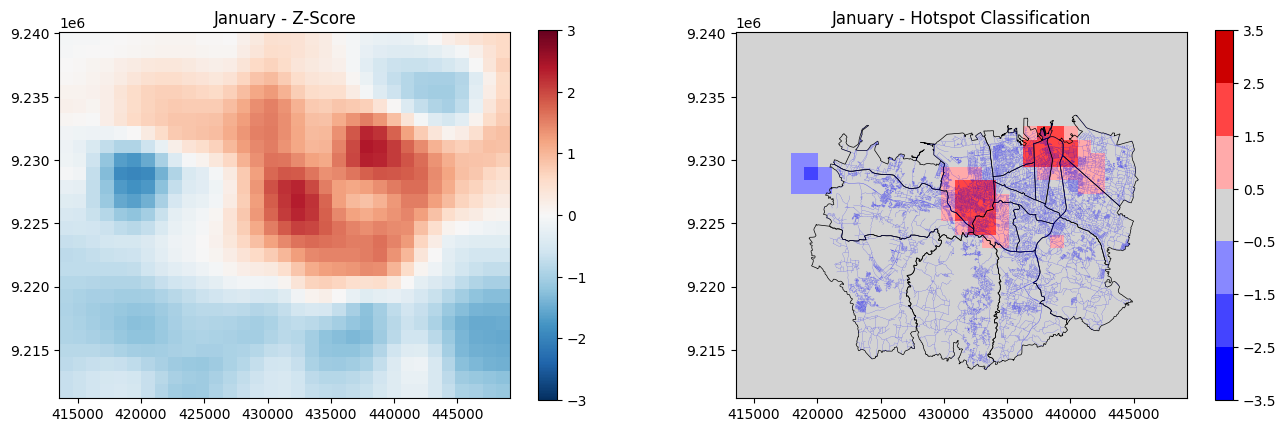


Bulan ke-2


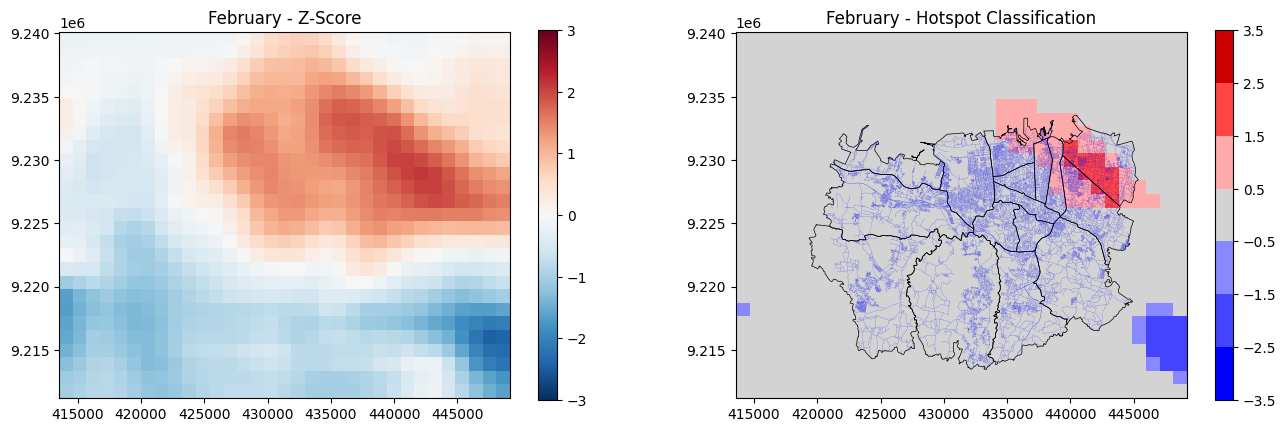


Bulan ke-3


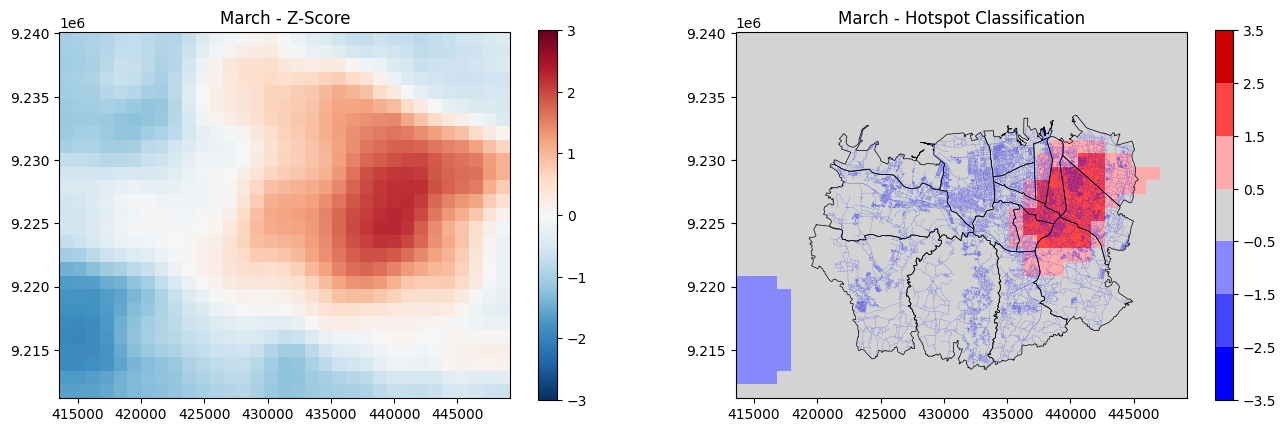


Bulan ke-4


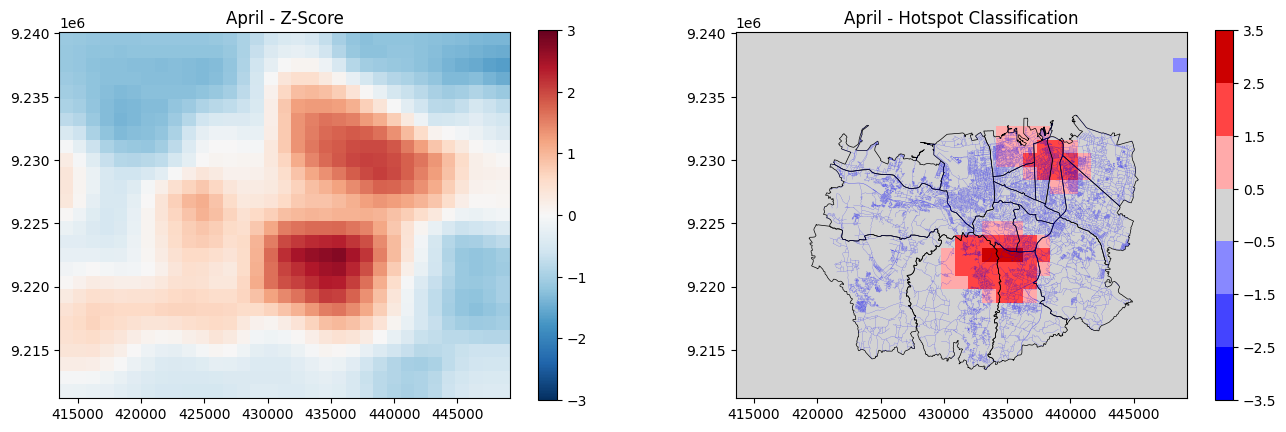


Bulan ke-5


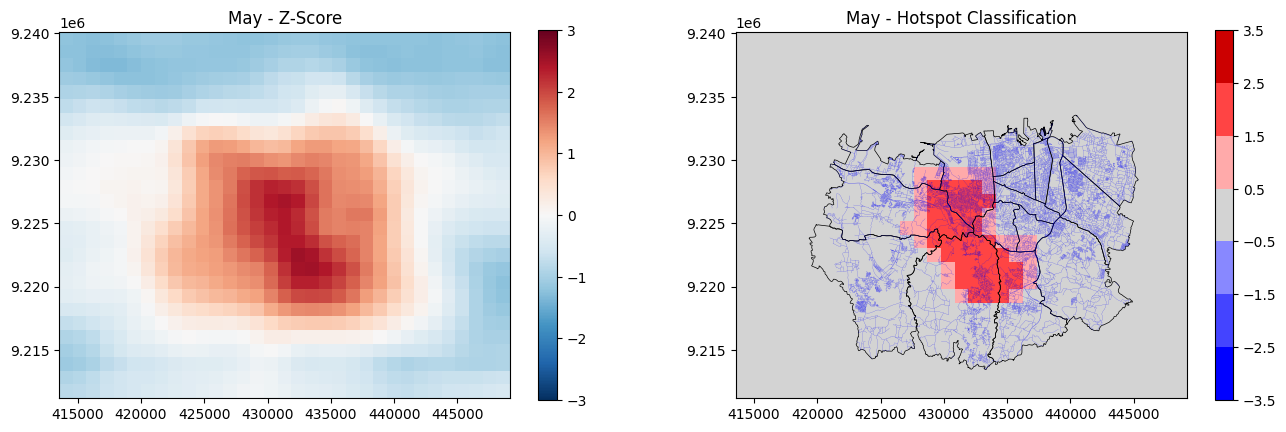


Bulan ke-6


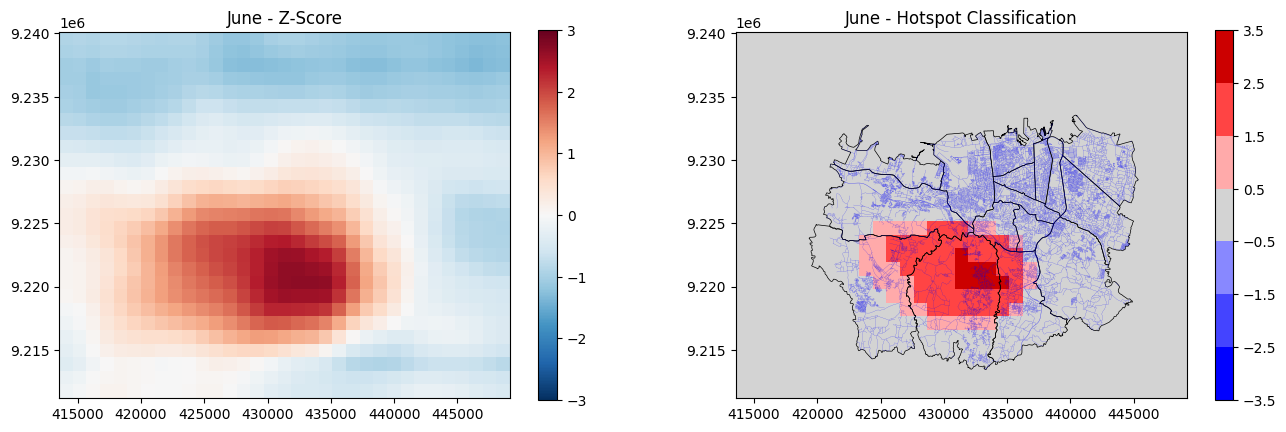

In [36]:
for i, m in enumerate(months):

    print(f"\nBulan ke-{m}")

    data_month = no2_monthly.sel(month=m)

    nodata_val = no2_vcd.rio.nodata
    if nodata_val is not None:
        data_month = data_month.where(data_month != nodata_val)

    no2_array = data_month.values
    no2_flat = no2_array.flatten()

    valid_mask = ~np.isnan(no2_flat)
    no2_valid = no2_flat.copy()
    no2_valid[~valid_mask] = 0

    # Spatial weight
    w = lat2W(nrows, ncols, rook=False)
    w.transform = 'r'

    g_local = G_Local(no2_valid, w, star=True)

    z_scores_2d = g_local.Zs.reshape(nrows, ncols)
    p_values_2d = g_local.p_sim.reshape(nrows, ncols)

    z_scores_2d[~valid_mask.reshape(nrows, ncols)] = np.nan
    p_values_2d[~valid_mask.reshape(nrows, ncols)] = np.nan

    classification = np.zeros(no2_array.shape)

    classification[(z_scores_2d >= 1.645) & (p_values_2d < 0.10)] = 1
    classification[(z_scores_2d >= 1.960) & (p_values_2d < 0.05)] = 2
    classification[(z_scores_2d >= 2.576) & (p_values_2d < 0.01)] = 3

    classification[(z_scores_2d <= -1.645) & (p_values_2d < 0.10)] = -1
    classification[(z_scores_2d <= -1.960) & (p_values_2d < 0.05)] = -2
    classification[(z_scores_2d <= -2.576) & (p_values_2d < 0.01)] = -3

    classification[~valid_mask.reshape(nrows, ncols)] = np.nan

    #  Plot langsung 
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    im1 = axes[0].imshow(z_scores_2d, extent=[lons.min(), lons.max(), lats.min(), lats.max()],
                         origin='upper', cmap='RdBu_r', vmin=-3, vmax=3)
    plt.colorbar(im1, ax=axes[0], shrink=0.8)
    axes[0].set_title(f'{month_names[i]} - Z-Score')
    
    im2 = axes[1].imshow(classification, extent=[lons.min(), lons.max(), lats.min(), lats.max()],
                         origin='upper', cmap=cmap_gs, norm=norm)
    axes[1].set_title(f'{month_names[i]} - Hotspot Classification')
    
    
    shapefile_kec.boundary.plot(ax=axes[1], edgecolor='black', linewidth=0.5)
    shapefile_jln.plot(ax=axes[1], color='blue', linewidth=0.1)
    
    plt.colorbar(im2, ax=axes[1], shrink=0.8)
    plt.show()
    plt.close()

1. Identifikasi sumber emisi lokal (pakai Percentile)
mendeteksi:
jalan tol,
kawasan industri,
power plant
2. Identifikasi wilayah polusi regional (pakai Gi*)
mendeteksi:
urban plume,
akumulasi polusi,
regional transport